# Ensemble Methods

Bagging, AdaBoost, Gradient Boosting, Voting. Binary classification on California housing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier,
                              RandomForestClassifier)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(13828, 13) (6812, 13)


## Bagging

Sample with replacement, fit a tree per sample, average the predictions. Reduces variance, doesn't really help with bias — so it's most useful with high-variance base learners like deep trees.

In [2]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, random_state=42),
    n_estimators=100, random_state=42, n_jobs=-1
)
bag.fit(X_train, y_train)
print(f"Bagging test acc: {accuracy_score(y_test, bag.predict(X_test)):.4f}")

Bagging test acc: 0.8698


## AdaBoost

Each round upweights the samples the previous learner got wrong. With weighted error $\epsilon_t$:

$$\alpha_t = \frac{1}{2} \log \frac{1 - \epsilon_t}{\epsilon_t}, \quad w_i \leftarrow w_i \exp(-\alpha_t y_i \hat y_i)$$

Then renormalize. Subsequent learners focus on the hard cases the ensemble can't yet classify.

AdaBoost test acc: 0.8541


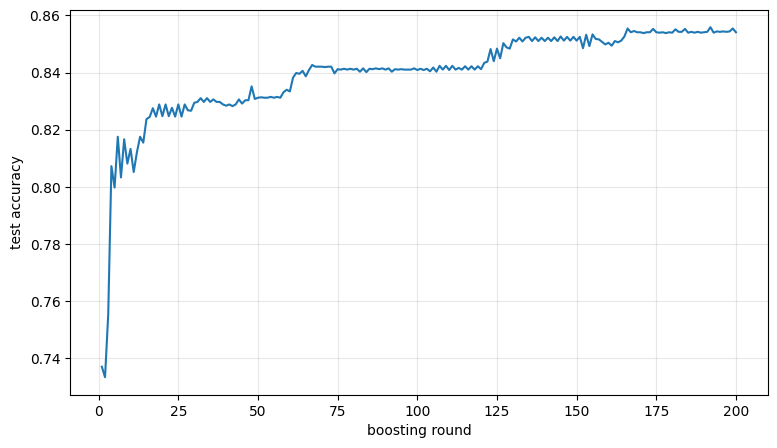

In [3]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200, learning_rate=1.0, random_state=42
)
ada.fit(X_train, y_train)
print(f"AdaBoost test acc: {accuracy_score(y_test, ada.predict(X_test)):.4f}")

stages = list(ada.staged_score(X_test, y_test))
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(stages) + 1), stages)
plt.xlabel('boosting round')
plt.ylabel('test accuracy')
plt.grid(alpha=0.3)
plt.show()

## Gradient Boosting

Each new tree fits the gradient of the loss at the current ensemble:

$$F_{m+1}(x) = F_m(x) + \nu \cdot h_m(x)$$

where $\nu$ is the learning rate and $h_m$ is a regression tree fit to the residuals. Slower than AdaBoost but usually more accurate.

GBM test acc: 0.8905


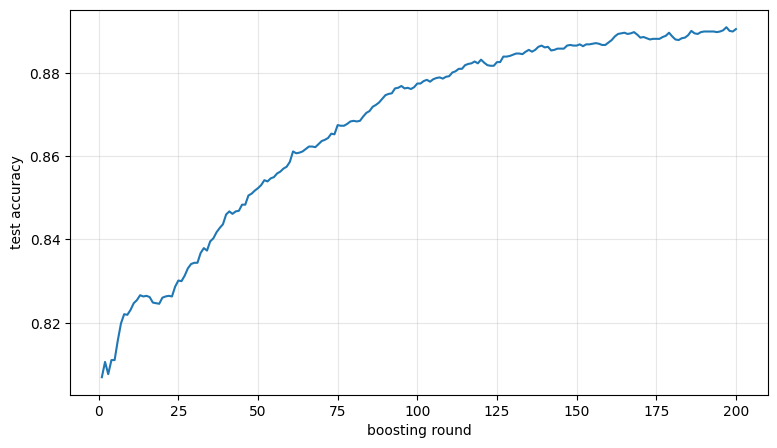

In [4]:
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
)
gb.fit(X_train, y_train)
print(f"GBM test acc: {accuracy_score(y_test, gb.predict(X_test)):.4f}")

gb_stages = [accuracy_score(y_test, (s > 0).astype(int))
             for s in gb.staged_decision_function(X_test)]

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(gb_stages) + 1), gb_stages)
plt.xlabel('boosting round')
plt.ylabel('test accuracy')
plt.grid(alpha=0.3)
plt.show()

## Learning rate sweep (GBM)

GBM is the most learning-rate-sensitive of these — too high and it overfits fast, too low and it never gets there in `n_estimators` rounds. Smaller `lr` + more trees is the standard recipe when you have the compute.

In [5]:
lrs = [0.01, 0.05, 0.1, 0.3, 0.5]
for lr in lrs:
    m = GradientBoostingClassifier(n_estimators=200, learning_rate=lr,
                                   max_depth=3, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f"lr={lr:<5} train={tr:.4f} test={te:.4f}")

lr=0.01  train=0.8269 test=0.8259


lr=0.05  train=0.8817 test=0.8742


lr=0.1   train=0.9040 test=0.8905


lr=0.3   train=0.9380 test=0.9003


lr=0.5   train=0.9542 test=0.8989


## Voting (hard and soft)

Combine the previous classifiers. Hard voting = majority vote on the predicted classes, soft = average the predicted probabilities. Soft usually wins when the base models are well-calibrated, since it preserves the confidence information that hard voting throws away.

In [6]:
estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('knn', KNeighborsClassifier(n_neighbors=15)),
]

vote_hard = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
vote_hard.fit(X_train, y_train)
print(f"Hard voting test acc: {accuracy_score(y_test, vote_hard.predict(X_test)):.4f}")

vote_soft = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
vote_soft.fit(X_train, y_train)
print(f"Soft voting test acc: {accuracy_score(y_test, vote_soft.predict(X_test)):.4f}")

Hard voting test acc: 0.8746


Soft voting test acc: 0.8748


## Compare all

Side-by-side bar chart of test accuracy across every method. GBM and the random forest typically lead by a small margin; bagging and AdaBoost trail by a few tenths of a percent.

Bagging          0.8698
AdaBoost         0.8541
GradientBoost    0.8905


Voting (hard)    0.8746


Voting (soft)    0.8748


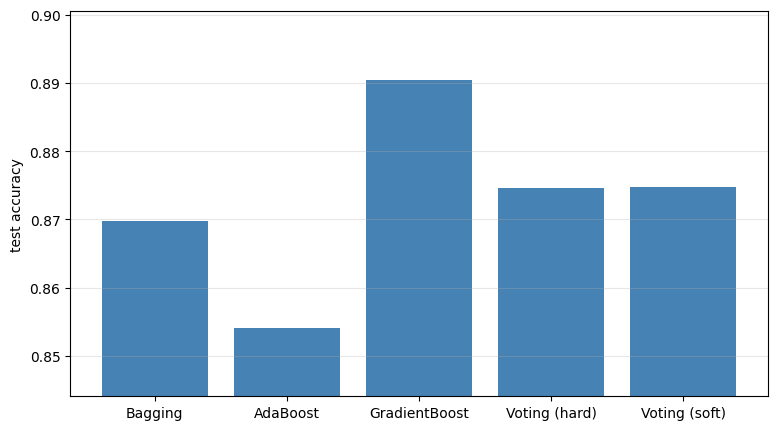

In [7]:
models = {
    'Bagging': bag,
    'AdaBoost': ada,
    'GradientBoost': gb,
    'Voting (hard)': vote_hard,
    'Voting (soft)': vote_soft,
}

names, accs = [], []
for name, m in models.items():
    a = accuracy_score(y_test, m.predict(X_test))
    names.append(name)
    accs.append(a)
    print(f"{name:<16} {a:.4f}")

plt.figure(figsize=(9, 5))
plt.bar(names, accs, color='steelblue')
plt.ylabel('test accuracy')
plt.ylim(min(accs) - 0.01, max(accs) + 0.01)
plt.grid(alpha=0.3, axis='y')
plt.show()

## From-scratch (rice_ml)

From-scratch bagging, AdaBoost, and GBM. Subsampled for speed.

In [8]:
from rice_ml.supervised_ml import (
    BaggingClassifier as RMBagging,
    AdaBoostClassifier as RMAda,
    GradientBoostingClassifier as RMGB,
)

rng_s = np.random.default_rng(42)
sub = rng_s.choice(len(X_train), 1500, replace=False)
Xs, ys = X_train[sub], y_train[sub]

bag_s = RMBagging(n_estimators=15, max_depth=4, seed=42).fit(Xs, ys)
ada_s = RMAda(n_estimators=30, seed=42).fit(Xs, ys)
gb_s  = RMGB(n_estimators=30, lr=0.1, max_depth=3, seed=42).fit(Xs, ys)

print(f"Bagging   from-scratch: {bag_s.score(X_test, y_test):.4f}  sklearn: {accuracy_score(y_test, bag.predict(X_test)):.4f}")
print(f"AdaBoost  from-scratch: {ada_s.score(X_test, y_test):.4f}  sklearn: {accuracy_score(y_test, ada.predict(X_test)):.4f}")
print(f"GBM       from-scratch: {gb_s.score(X_test, y_test):.4f}  sklearn: {accuracy_score(y_test, gb.predict(X_test)):.4f}")

Bagging   from-scratch: 0.8199  sklearn: 0.8698
AdaBoost  from-scratch: 0.8315  sklearn: 0.8541
GBM       from-scratch: 0.8023  sklearn: 0.8905
